In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold, validation_curve, learning_curve, cross_validate
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, ElasticNet, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, LabelEncoder
from xgboost import XGBClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report

import warnings
warnings.simplefilter(action = 'ignore')


In [2]:
df = pd.read_excel('/kaggle/input/ecommerce-customer-churn-analysis-and-prediction/E Commerce Dataset.xlsx',
                  sheet_name = 'E Comm')
df.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [3]:
df.shape

(5630, 20)

In [4]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [5]:
df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [6]:
df.drop(['CustomerID'], axis = 1, inplace = True)

In [7]:
df.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [8]:
df.isnull().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        5630 non-null   int64  
 1   Tenure                       5366 non-null   float64
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5379 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5375 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain          

In [10]:
df.describe()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [11]:
df.nunique()

Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64

In [12]:
obj_col = df.select_dtypes(include = 'O').columns

In [13]:
obj_col

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [14]:
def unique_values(df, col):
    entries = []
    entries = df[col].unique()
    print(f"{col} Unique Entries")
    print(df[col].value_counts())
    print()
    print(entries)
    print()

In [15]:
for i in obj_col:
    unique_values(df, i)
    print()

PreferredLoginDevice Unique Entries
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

['Mobile Phone' 'Phone' 'Computer']


PreferredPaymentMode Unique Entries
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']


Gender Unique Entries
Gender
Male      3384
Female    2246
Name: count, dtype: int64

['Female' 'Male']


PreferedOrderCat Unique Entries
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


MaritalStatus Unique Entries
MaritalStatus
Married     2

In [16]:
df.loc[df['PreferredPaymentMode'] == 'COD', 'PreferredPaymentMode' ] = 'Cash Payment'
df.loc[df['PreferredPaymentMode'] == 'Cash on Delivery', 'PreferredPaymentMode' ] = 'Cash Payment'
df.loc[df['PreferredPaymentMode'] == 'CC', 'PreferredPaymentMode' ]  =  'Card Payment'
df.loc[df['PreferredPaymentMode'] == 'Debit Card', 'PreferredPaymentMode' ]  =  'Card Payment'
df.loc[df['PreferredPaymentMode'] == 'Credit Card', 'PreferredPaymentMode' ]  =  'Card Payment'
df.loc[df['PreferredPaymentMode'] == 'E wallet', 'PreferredPaymentMode' ]  =  'Digital Payment'
df.loc[df['PreferredPaymentMode'] == 'UPI', 'PreferredPaymentMode' ]  =  'Digital Payment'
df.loc[df['PreferedOrderCat'] == 'Mobile', 'PreferedOrderCat' ]  =  'Mobile Phone'
df.loc[df['PreferredLoginDevice'] == 'Phone', 'PreferredLoginDevice' ]  =  'Mobile Phone'

In [17]:
for i in obj_col:
    unique_values(df, i)
    print()

PreferredLoginDevice Unique Entries
PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64

['Mobile Phone' 'Computer']


PreferredPaymentMode Unique Entries
PreferredPaymentMode
Card Payment       4088
Digital Payment    1028
Cash Payment        514
Name: count, dtype: int64

['Card Payment' 'Digital Payment' 'Cash Payment']


Gender Unique Entries
Gender
Male      3384
Female    2246
Name: count, dtype: int64

['Female' 'Male']


PreferedOrderCat Unique Entries
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


MaritalStatus Unique Entries
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

['Single' 'Divorced' 'Married']




In [18]:
df.duplicated().sum()

557

In [19]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5625     True
5626    False
5627    False
5628     True
5629    False
Length: 5630, dtype: bool

In [20]:
df.drop_duplicates(keep = 'first', inplace = True)

In [21]:
df.duplicated().sum()

0

In [22]:
columns = df.columns

In [23]:
columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [24]:
grouped_data = []
for i in df.columns:
    missing = df[i].isnull().sum()
    percentage = missing/df.shape[0]*100
    grouped_data.append([i, missing, percentage])
missing_df = pd.DataFrame(grouped_data, columns = ['Column', 'Missing_values', 'Missing_percentage'])
    

In [25]:
missing_df

,Column,Missing_values,Missing_percentage
0,Churn,0,0.000000
1,Tenure,231,4.553519
2,PreferredLoginDevice,0,0.000000
3,CityTier,0,0.000000
4,WarehouseToHome,221,4.356397
5,PreferredPaymentMode,0,0.000000
6,Gender,0,0.000000
7,HourSpendOnApp,230,4.533806
8,NumberOfDeviceRegistered,0,0.000000
9,PreferedOrderCat,0,0.000000


In [26]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [27]:
from ydata_profiling import ProfileReport
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 19/19 [00:00<00:00, 66.95it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

binary_cat_cols = ['Complain']
outcome = ['Churn']
cat_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode',
       'Gender', 'NumberOfDeviceRegistered', 'PreferedOrderCat',
       'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain']
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

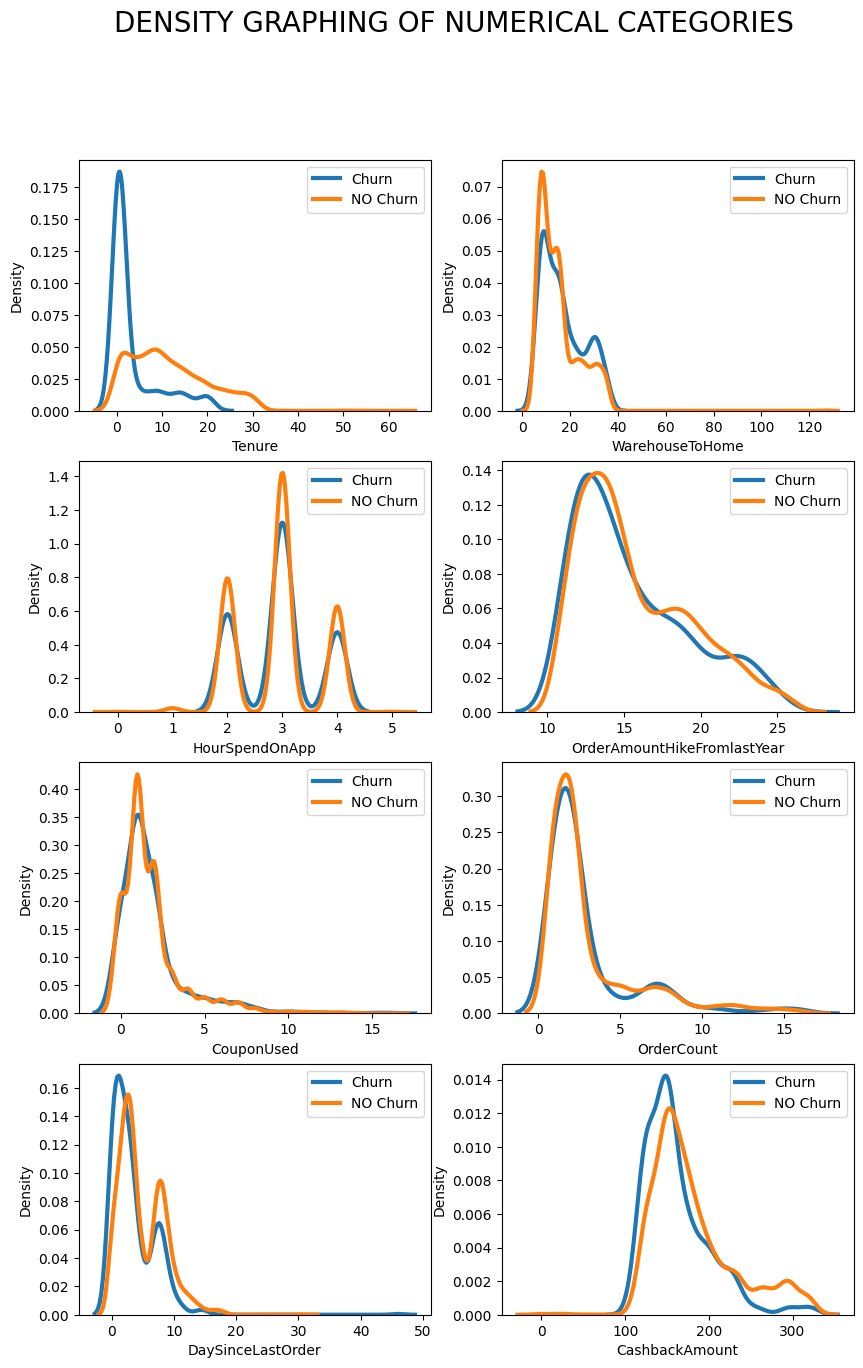

In [29]:
df_c = df[df['Churn'] == 1].copy()
df_nc = df[df['Churn'] == 0].copy()

fig, ax = plt.subplots(4, 2, figsize = (10,15))
fig.suptitle("DENSITY GRAPHING OF NUMERICAL CATEGORIES", fontsize = 20)
ax = ax.flatten()
for idx, col in enumerate(num_cols):
    sns.kdeplot(df_c[col], linewidth = 3, label = 'Churn', ax = ax[idx])
    sns.kdeplot(df_nc[col], linewidth = 3, label = 'NO Churn', ax = ax[idx])
    ax[idx].legend(loc = 'upper right')
plt.show()

IndexError: index 8 is out of bounds for axis 0 with size 8

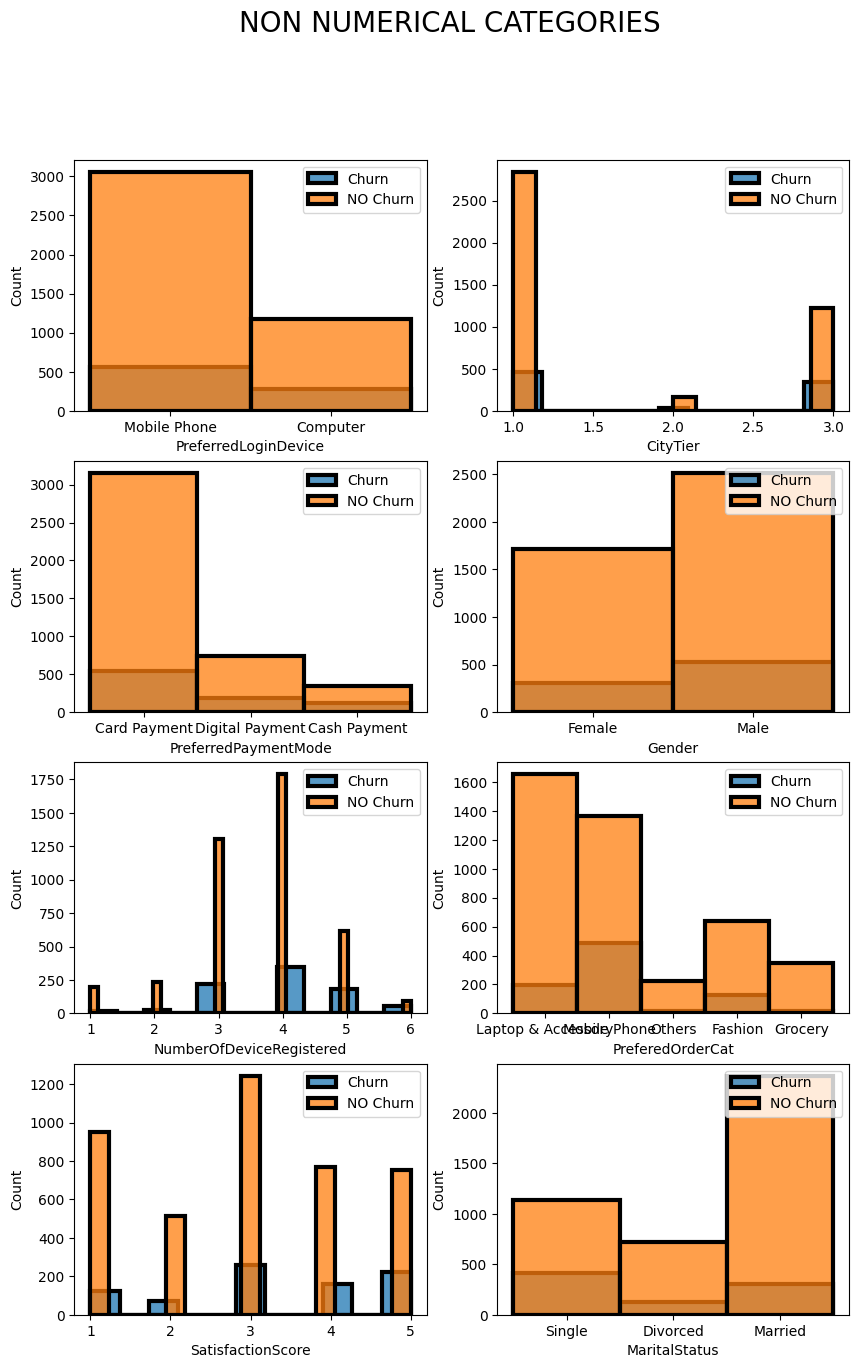

In [30]:
fig, ax = plt.subplots(4, 2, figsize = (10,15))
fig.suptitle("NON NUMERICAL CATEGORIES", fontsize = 20)
ax = ax.flatten()
for idx, col in enumerate(cat_cols):
    sns.histplot(df_c[col], linewidth = 3, label = 'Churn', ax = ax[idx])
    sns.histplot(df_nc[col], linewidth = 3, label = 'NO Churn', ax = ax[idx])
    ax[idx].legend(loc = 'upper right')
plt.show()

In [ ]:
df.groupby('Churn')['PreferredLoginDevice'].value_counts()

In [ ]:
df.groupby('PreferredLoginDevice')['OrderCount'].value_counts()

In [ ]:
df.groupby('PreferredLoginDevice')['PreferedOrderCat'].value_counts()

In [ ]:
df.groupby('PreferredLoginDevice')['CityTier'].value_counts()

In [ ]:
df.groupby('PreferredLoginDevice')['Complain'].value_counts()

In [ ]:
import plotly.express as ps
percentage_complain_ComputerGuys = 401/1056
percentage_complain_mobileGuys = 1033/2583
percentages = [percentage_complain_ComputerGuys, percentage_complain_mobileGuys]
plt.bar(['Complaint@Comp','Complaint@Phone'], [percentage_complain_ComputerGuys, percentage_complain_mobileGuys], color = ['orange', 'red'])

plt.ylabel('Percentage')
plt.title('Complaint Rate Comparison')
plt.ylim(0, 1)

# Display the values on top of the bars
for i, v in enumerate(percentages):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')

plt.show()

In [ ]:
# People ordering from phone are having more issues in comparision to that using PCs. So, company should focus on improving user experience keeping phone logged in users as first priority.

In [ ]:
df.describe(include= 'O')

**Gender**

In [ ]:
df.columns

In [ ]:
df['Gender'].value_counts()

In [ ]:
df.groupby('Churn')['Gender'].value_counts()

In [ ]:
fig, ax =plt.subplots(1,1, figsize = (5, 5))
fig.suptitle('GENDER Vs CHURN')
sns.histplot(df['Gender'][df['Gender'] == 'Male'], ax = ax, label = "Male")
sns.histplot(df['Gender'][df['Gender'] == "Female"], ax = ax, label = "Female")
plt.show()

In [ ]:
gender_churncount = df.groupby('Gender')['Churn'].mean().plot(kind = 'bar')
gender_churncount

In [ ]:
df.groupby('Gender')['Complain'].value_counts()

In [ ]:
#almost same percentage of complaint by both the genders

In [ ]:
gender_ordercount = df.groupby('Gender')['OrderCount'].mean().plot(kind = 'bar')
gender_ordercount

In [ ]:
df.SatisfactionScore.dtype

In [ ]:
num_cols

In [ ]:
df_m = df[df['Gender']=='Male'].copy()
df_f = df[df['Gender']== 'Female'].copy()

fig, ax = plt.subplots(2,4,figsize=(20, 15))
fig.suptitle('Male Vs Female Comparision')
ax = ax.flatten()

for idx, c in enumerate(num_cols):
    sns.kdeplot(df_m[c], linewidth = 3, label = 'Male', ax = ax[idx])
    sns.kdeplot(df_f[c], linewidth = 3, label = 'Female', ax = ax[idx])
    ax[idx].legend(loc = 'upper right')
plt.show()

In [ ]:
gender_ordercount = df.groupby('Gender')['SatisfactionScore'].mean().plot(kind = 'bar')
gender_ordercount

In [ ]:
import plotly.express as px

churn_counts = df.groupby('Churn')['Gender'].value_counts().reset_index(name='Count')

# Now plot the new DataFrame, using the 'Count' column for values
# and 'Churn' for the names (slices of the pie).
fig = px.pie(churn_counts,
             values='Count',
             names='Churn',
             color='Gender', # Use the 'Gender' column to assign colors to the slices
             title='Churn Rate by Gender')

# Update the layout and traces. Use valid color names or hex codes.
# 'pink' is valid, but 'baby green' is not. Let's use 'lightgreen' instead.
fig.update_traces(marker=dict(colors=['pink', 'lightgreen']))

# The legend title is handled automatically by the 'color' parameter in px.pie
# but you can still customize it like this:
fig.update_layout(
    legend_title='Gender'
)

fig.show()

In [ ]:
#avg churnoutrate of male > avg churn of female
#avg ordercount of male < avg ordercount of female
# More male prefer short term tenure
# When it comes to chashback > 200, its more likely for a female to get it easily.
# Avg satisfaction score of Female > male

#Finally, company should focus on improving the experience of males by some offers, or showcasing ads or products of their types,etc.

**Which MartialStatus has the highest Churn rate?**

In [ ]:
df.groupby('Churn')['MaritalStatus'].value_counts()

In [ ]:
churn_counts = df.groupby('MaritalStatus')['Churn'].value_counts().unstack()
churn_counts

In [ ]:
churn_counts.columns

In [ ]:
sns.countplot(x='MaritalStatus', hue = 'Churn', data = df, palette = 'mako')
plt.title("churn Rates by MaritalStatus")
plt.ylabel("Churn Rate")

In [ ]:
churn_maritalStatus = df.groupby('MaritalStatus')['Churn'].mean().plot(kind = 'bar', color = '#2F4B26')
churn_maritalStatus

In [ ]:
# color palettes
pie_palette = ['#3E885B','#7694B6','#85BDA6', '#80AEBD', '#2F4B26', '#3A506B']
green_palette = ['#2F4B26', '#3E885B', '#85BDA6', '#BEDCFE', '#C0D7BB']
blue_palette = ['#3A506B', '#7694B6', '#80AEBD', '#5BC0BE', '#3E92CC']
custom_palette = ['#3A506B', '#7694B6', '#80AEBD', '#3E885B', '#85BDA6']
red_palette = ['#410B13', '#CD5D67', '#BA1F33', '#421820', '#91171F']

In [ ]:
marital_status_counts = df['MaritalStatus'].value_counts().reset_index()
marital_status_counts.columns = ['MaritalStatus', 'Count']

# Create the donut chart using plotly.express
fig = px.pie(
    marital_status_counts,
    values='Count',
    names='MaritalStatus',
    # Adds a hole in the center to create a donut chart
    hole=0.4,
    # A professional, brand-friendly color palette
    color_discrete_sequence=px.colors.sequential.Tealgrn,
    title='<b>Audience Distribution by Marital Status</b>'
)

# Customize the text displayed on the slices and in the tooltip
fig.update_traces(
    textposition='outside', # Places the percentage and label outside the slices
    textinfo='percent+label',
    # Customize what shows up when you hover over a slice
    hoverinfo='label+percent+value',
    # Sets the inner text to a radial orientation for better readability
    insidetextorientation='radial',
    # Make the lines between the slices thicker and a nice color
    marker=dict(line=dict(color='white', width=2))
)

# Update the layout to make the chart more polished
fig.update_layout(
    # Move the legend to the right side
    legend_title_text='Marital Status',
    # Customize the title font and size
    title_font_size=20,
    # Remove the animation for better performance if there are many slices
    hoverlabel=dict(bgcolor="white", font_size=16, font_family="Lato")
)

# Display the chart
fig.show()

In [ ]:
#Married people has the highest segemnt of customer and largest churn rate are of singles, so company must take some steps in order to engage and retain single population

**3-Which CityTier has higher WarehouseToHome, Tenure, OrderAmountHikeFromlastYear and OrderCount?**

In [ ]:
df.columns

In [ ]:
df.CityTier.dtype

In [ ]:
city_tier_mapping = {
    1: 'Tier 1',
    2: 'Tier 2',
    3: 'Tier 3'
}
df['mapped_City_Tier'] = df['CityTier'].map(city_tier_mapping)
city_tier_counts = df['mapped_City_Tier'].value_counts().reset_index()
city_tier_counts.columns = ['CityTier', 'Count']

# Create the donut chart using plotly.express
fig = px.pie(
    city_tier_counts,
    values='Count',
    names='CityTier',
    # Adds a hole in the center to create a donut chart
    hole=0.4,
    # A professional color palette, different from the previous one for variety
    color_discrete_sequence=px.colors.sequential.PuBu,
    title='<b>Audience Distribution by City Tier</b>'
)

# Customize the text displayed on the slices and in the tooltip
fig.update_traces(
    textposition='outside',
    textinfo='percent+label',
    hoverinfo='label+percent+value',
    insidetextorientation='radial',
    # Make the lines between the slices thicker and a nice color
    marker=dict(line=dict(color='white', width=2))
)

# Update the layout to make the chart more polished
fig.update_layout(
    # Set the legend title
    legend_title_text='City Tier',
    # Customize the title font and size
    title_font_size=20,
    # Customize the hover box appearance
    hoverlabel=dict(bgcolor="white", font_size=16, font_family="Lato")
)

# Display the chart
fig.show()



In [ ]:
# maximum customers from tier 1 city, minimum from tier 2

In [ ]:
sns.boxplot(x = 'CityTier', y = 'WarehouseToHome', data = df, palette = 'pastel')

In [ ]:
#company should try to reduce warehousetothome time in tier 1 and tier 3 cities.

In [ ]:
churn_citytier = df.groupby('CityTier')['Churn'].mean()
ax = churn_citytier.plot(kind = 'bar', color = 'lightpink', edgecolor = 'black')
plt.xticks(rotation = 360)
plt.xlabel('City Tier', fontweight = 'bold')
plt.ylabel('Mean Churn Rate (Percentage)', fontweight = 'bold')
for i, v in enumerate(churn_citytier.values):
    text = f'{v:.2%}'
    ax.text(
        x = i,
        y = v,
        s = text,
        ha = 'center',
        va = 'bottom',
        color = 'black',
        fontweight = 'bold'
    )
plt.tight_layout()
plt.show()


In [ ]:
g = sns.FacetGrid(df, col = 'CityTier')
g.map(sns.distplot, 'HourSpendOnApp', color = 'lightGreen')

Tier 1: The presence of three distinct peaks in Tier 1 suggests three clear user segments. This is likely the company's most diverse user base in terms of engagement.

Tier 2: The less distinct peaks in Tier 2 suggest a more "average" user base with less extreme behavior. Users are more evenly distributed across different engagement levels.A one-size-fits-all strategy might work better here than in Tier 1.

Tier 3: Focus on Two Core User Groups.The two primary peaks in Tier 3 indicate two dominant user segments: the casual user and the highly engaged user. The moderate user segment is less common.The company should focus its efforts on improving the experience for these two core groups. They might want to investigate why there are so few moderate users—are there features missing that would encourage short-term users to spend more time on the app? They could also develop strong content for their most engaged users to retain them.

In [ ]:
df_tenure = df.groupby('CityTier')['Tenure'].agg(['mean','max','min'])
df_tenure

In [ ]:
df_ordercount = df.groupby('CityTier')['OrderCount'].agg(['mean','max','min'])
df_ordercount

In [ ]:
fig = px.histogram(df, x="HourSpendOnApp", y="SatisfactionScore", orientation="h", color="Churn" ,text_auto= True , title="<b>"+'HourSpendOnApp Vs SatisfactionScore' , color_discrete_sequence = ['#BA1F33','#3A506B','#3E885B'])

# Customize the plot
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='HourSpendOnApp',
yaxis_title='SatisfactionScore',
)
fig.show()

No solid relation b/w them

In [ ]:
sns.violinplot(x='CityTier', y='NumberOfAddress', data=df[df['Churn']==1])

In [ ]:
ax = sns.histplot(
    data=df, 
    x='NumberOfAddress', 
    hue='Churn', 
    multiple='stack', # 'stack' stacks the bars for each hue category
    palette='viridis',
    kde=True # Add a kernel density estimate line for a smoother visualization
)

# Set the title and labels for clarity
plt.title('Distribution of Number of Addresses by Churn Status', fontweight='bold')
plt.xlabel('Number of Addresses', fontweight='bold')
plt.ylabel('Count', fontweight='bold')

# Adjust the plot layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
#some sort of negative correlation between no. of adress and churn

In [ ]:
df[['DaySinceLastOrder', 'Complain']].corr()

In [ ]:
logindevice_Churn = df.groupby('PreferredLoginDevice')['Churn'].mean().plot(kind='bar')

In [ ]:
#company should try improving the experience of user with compute login.

**Does different citytiers has different prefered products**|

In [ ]:
fig = px.histogram(df, x = 'PreferedOrderCat', facet_col = 'CityTier', color = 'CityTier',
                  color_discrete_sequence = green_palette, text_auto = True, title ="<b>"+'CityTier Vs PreferedOrderCat')
fig.update_layout(hovermode = 'x', title_font_size = 30)
fig.update_layout(
    title_font_color = "Black",
    template = 'plotly',
    hoverlabel_font_size = 30,
    title_x=0.5,
    xaxis_title='PreferredPaymentMode',
     yaxis_title='count',
)
plt.tight_layout()
fig.show()

In [ ]:
# almost in all cities,laptops and mobile phones are most purchased....

**PreferredPaymentMode Vs CHURN**

In [ ]:
df.groupby('PreferredPaymentMode')['Churn'].mean().plot(kind = 'bar', color = 'green')

In [ ]:
churn_payment = df.groupby('PreferredPaymentMode')['Churn'].mean()
ax = churn_payment.plot(kind = 'bar', color=sns.color_palette("viridis"), edgecolor = 'black')
plt.xticks(rotation = 360)
plt.xlabel('City Tier', fontweight = 'bold')
plt.ylabel('Mean Churn Rate (Percentage)', fontweight = 'bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(churn_payment.values):
    text = f'{v:.2%}'
    ax.text(
        x = i,
        y = v,
        s = text,
        ha = 'center',
        va = 'bottom',
        color = 'black',
        fontweight = 'bold'
    )
plt.tight_layout()
plt.show()

In [ ]:
'''company should work on finding the issue with cash payment which is causing users 
inconvinience. and also user experience should be imporved for digital payment by enchancing interface.'''

**Which CityTier has the highest OrderCount?**

In [ ]:
df.groupby('CityTier')['OrderCount'].sum()

In [ ]:
sns.violinplot(x='CityTier', y='OrderCount', data=df)

In [ ]:
#tier 1 city has highest order counts but average of all cities lies at same level.

In [ ]:
comp_ten = df.groupby(["OrderAmountHikeFromlastYear", "Churn"]).size().reset_index(name="Count")

# Create a bubble chart using Plotly
fig_bubble = px.scatter(comp_ten, x="OrderAmountHikeFromlastYear", y="Count", size="Count", color="Churn", title="<b>"+'OrderAmountHikeFromlastYear VS Churn',
                        color_discrete_sequence=["#d62728", "#1f77b4"])

# Customize the plot
fig_bubble.update_layout(hovermode='x',title_font_size=30)
fig_bubble.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='OrderAmountHikeFromlastYear',
yaxis_title='count',
)
fig_bubble.show()

In [ ]:
ax = sns.kdeplot(
    data=df, 
    x='OrderAmountHikeFromlastYear', 
    hue='Churn',
    fill=True, # Fills the area under the KDE line for better visualization
    palette='viridis',
    alpha=0.6, # Set transparency
    common_norm=False # Ensures each group's density is calculated independently
)

# Set the title and labels for clarity
plt.title('Distribution of Order Amount Hike by Churn Status', fontweight='bold')
plt.xlabel('Order Amount Hike from Last Year', fontweight='bold')
plt.ylabel('Density', fontweight='bold')

# Adjust the plot layout to prevent labels from being cut off
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# so company should focus that why at 8%-13% point hike is the sensitive part for the organization where large no. of audience quit.

order counts for customers with high HourSpendOnApp?

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

In [31]:
fig = px.histogram(
    df, 
    x='HourSpendOnApp',
    nbins=5, # You can adjust the number of bins
    histnorm='density', # Ensures the y-axis is a density plot
    marginal='box', # Adds a box plot on the margin for quick summary stats
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='<b>Distribution of Time Spent on App</b>'
)

# A KDE plot is a separate layer in plotly. This is how you add it.
# We'll calculate the KDE using a separate library like scipy if needed,
# but for this type of combined plot, the marginal box plot is a common
# way to show the distribution visually within Plotly itself.

# Customize the plot layout
fig.update_layout(
    xaxis_title='Hours Spent on App',
    yaxis_title='Density',
    title_font_size=20,
    title_x=0.5,
    bargap=0.05 # Adds a small gap between the bars
)

# Display the plot
fig.show()



NameError: name 'px' is not defined

In [32]:
fig = px.scatter(
    df, 
    x='HourSpendOnApp', 
    y='OrderCount',
    marginal_x='histogram', # Adds a histogram for HourSpendOnApp on the x-axis margin
    marginal_y='histogram', # Adds a histogram for NumberOfOrders on the y-axis margin
    color_discrete_sequence=px.colors.qualitative.Plotly, # A modern color palette
    title='<b>Order Count vs. Hours Spent on App</b>',
    hover_data={'HourSpendOnApp': True, 'OrderCount': True} # Shows both values on hover
)

# Customize the plot layout for a clean look
fig.update_layout(
    xaxis_title='Hours Spent on App',
    yaxis_title='Number of Orders',
    title_font_size=20,
    title_x=0.5,
)

# Display the plot
fig.show()



NameError: name 'px' is not defined

NameError: name 'order_hours' is not defined

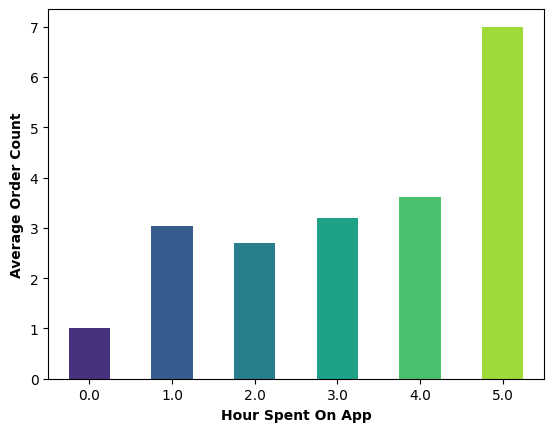

In [33]:
order_hour = df.groupby('HourSpendOnApp')['OrderCount'].mean()
kgg = order_hour.plot(kind = 'bar', color=sns.color_palette("viridis"))
plt.xlabel('Hour Spent On App', fontweight = 'bold')
plt.ylabel('Average Order Count', fontweight = 'bold')
plt.xticks(rotation = 360)
plt.plot(order_hour.index, order_hours.values)


In [34]:
#company should try to engage user more time on app in order to get more orders and make profit

In [35]:
gender_cat = pd.DataFrame(df.groupby('PreferedOrderCat')['Gender'].value_counts())
gender_cat

count
PreferedOrderCat   Gender       
Fashion            Male      438
                   Female    325
Grocery            Male      188
                   Female    178
Laptop & Accessory Male     1095
                   Female    752
Mobile Phone       Male     1162
                   Female    693
Others             Male      164
                   Female     78

In [36]:
import plotly.graph_objects as go

In [37]:
male_df = df[df['Gender'] == 'Male']['PreferedOrderCat'].value_counts().reset_index()
male_df.columns = ['PreferedOrderCat', 'Count']

female_df = df[df['Gender'] == 'Female']['PreferedOrderCat'].value_counts().reset_index()
female_df.columns = ['PreferedOrderCat', 'Count']

# Plotting both on the same graph using plotly.graph_objects
fig2 = go.Figure()
fig2.add_trace(go.Bar(x=male_df['PreferedOrderCat'], y=male_df['Count'], name='Male'))
fig2.add_trace(go.Bar(x=female_df['PreferedOrderCat'], y=female_df['Count'], name='Female'))

fig2.update_layout(barmode='group',
                   title="<b>Preferred Category vs Gender</b>",
                   title_font_color="black", template="plotly", title_font_size=30,
                   hoverlabel_font_size=20, title_x=0.5, xaxis_title='Preferred Order Category',
                   yaxis_title='Count', hovermode='x')

In [38]:
# Top Preferd Category For Males == > [ Laptop & acc., Mobile Phone, Grocery]
# Top Preferd Category For Females == > [ Laptop & acc., Mobile Phone,Fashion ]

There is relation between CashbackAmount and order counts within churn?

In [39]:
df.groupby(['OrderCount','CashbackAmount'])[['Churn']].count()

Churn
OrderCount CashbackAmount       
1.0        0.00                2
           56.00               1
           110.09              2
           110.51              2
           110.52              2
...                          ...
16.0       295.48              2
           296.23              2
           315.68              2
           320.37              1
           320.45              2

[2696 rows x 1 columns]

In [40]:
fig = px.histogram(df, x='CashbackAmount', y='OrderCount' ,color = 'Churn', title="<b>"+'CashbackAmount Vs OrderCount within churn', color_discrete_sequence=["#FA8072", "#98FB98"])

# Customize the plot
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='CashbackAmount',
yaxis_title='OrderCount',
)
fig.show()

NameError: name 'px' is not defined

In [41]:
#there is no relation between cash back amount and ordercount 

**Are customers who complained more likely to churn?**

In [42]:
df.groupby('Complain')[['Churn']].count()

,Churn
Complain,
0,3639
1,1434


In [43]:
churn_payment = df.groupby('Complain')['Churn'].mean()
churn_payment

Complain
0    0.107722
1    0.313110
Name: Churn, dtype: float64

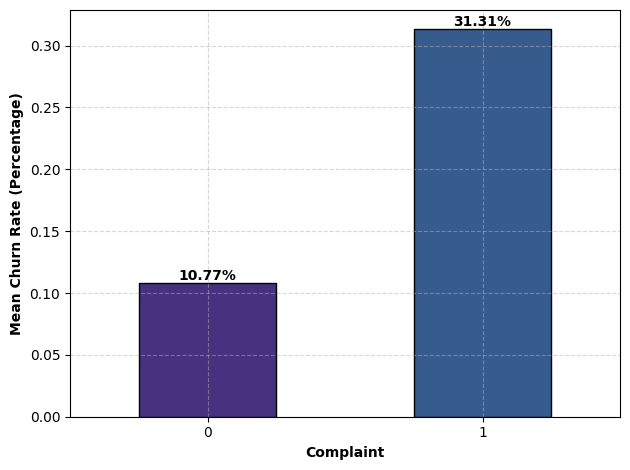

In [44]:
churn_payment = df.groupby('Complain')['Churn'].mean()
ax = churn_payment.plot(kind = 'bar', color=sns.color_palette("viridis"), edgecolor = 'black')
plt.xticks(rotation = 360)
plt.xlabel('Complaint', fontweight = 'bold')
plt.ylabel('Mean Churn Rate (Percentage)', fontweight = 'bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
for i, v in enumerate(churn_payment.values):
    text = f'{v:.2%}'
    ax.text(
        x = i,
        y = v,
        s = text,
        ha = 'center',
        va = 'bottom',
        color = 'black',
        fontweight = 'bold'
    )
plt.tight_layout()
plt.show()

In [45]:
#customers with complaint has higher chance of quitting. So, company must resolve their isuue asap.

***Data Preprocessing***

In [46]:
df.isnull().sum()

Churn                            0
Tenure                         231
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                221
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 230
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    252
CouponUsed                     210
OrderCount                     243
DaySinceLastOrder              288
CashbackAmount                   0
dtype: int64

In [47]:
df

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Card Payment,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Mobile Phone,1,8.0,Digital Payment,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Mobile Phone,1,30.0,Card Payment,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Mobile Phone,3,15.0,Card Payment,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Mobile Phone,1,12.0,Card Payment,Male,NaN,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,0,5.0,Computer,1,12.0,Card Payment,Male,4.0,4,Laptop & Accessory,5,Single,2,0,20.0,2.0,2.0,NaN,224.36
5624,0,1.0,Mobile Phone,3,12.0,Digital Payment,Female,2.0,5,Mobile Phone,3,Single,2,0,19.0,2.0,2.0,1.0,154.66
5626,0,13.0,Mobile Phone,1,13.0,Card Payment,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,0,1.0,Mobile Phone,1,11.0,Card Payment,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42


<Axes: >

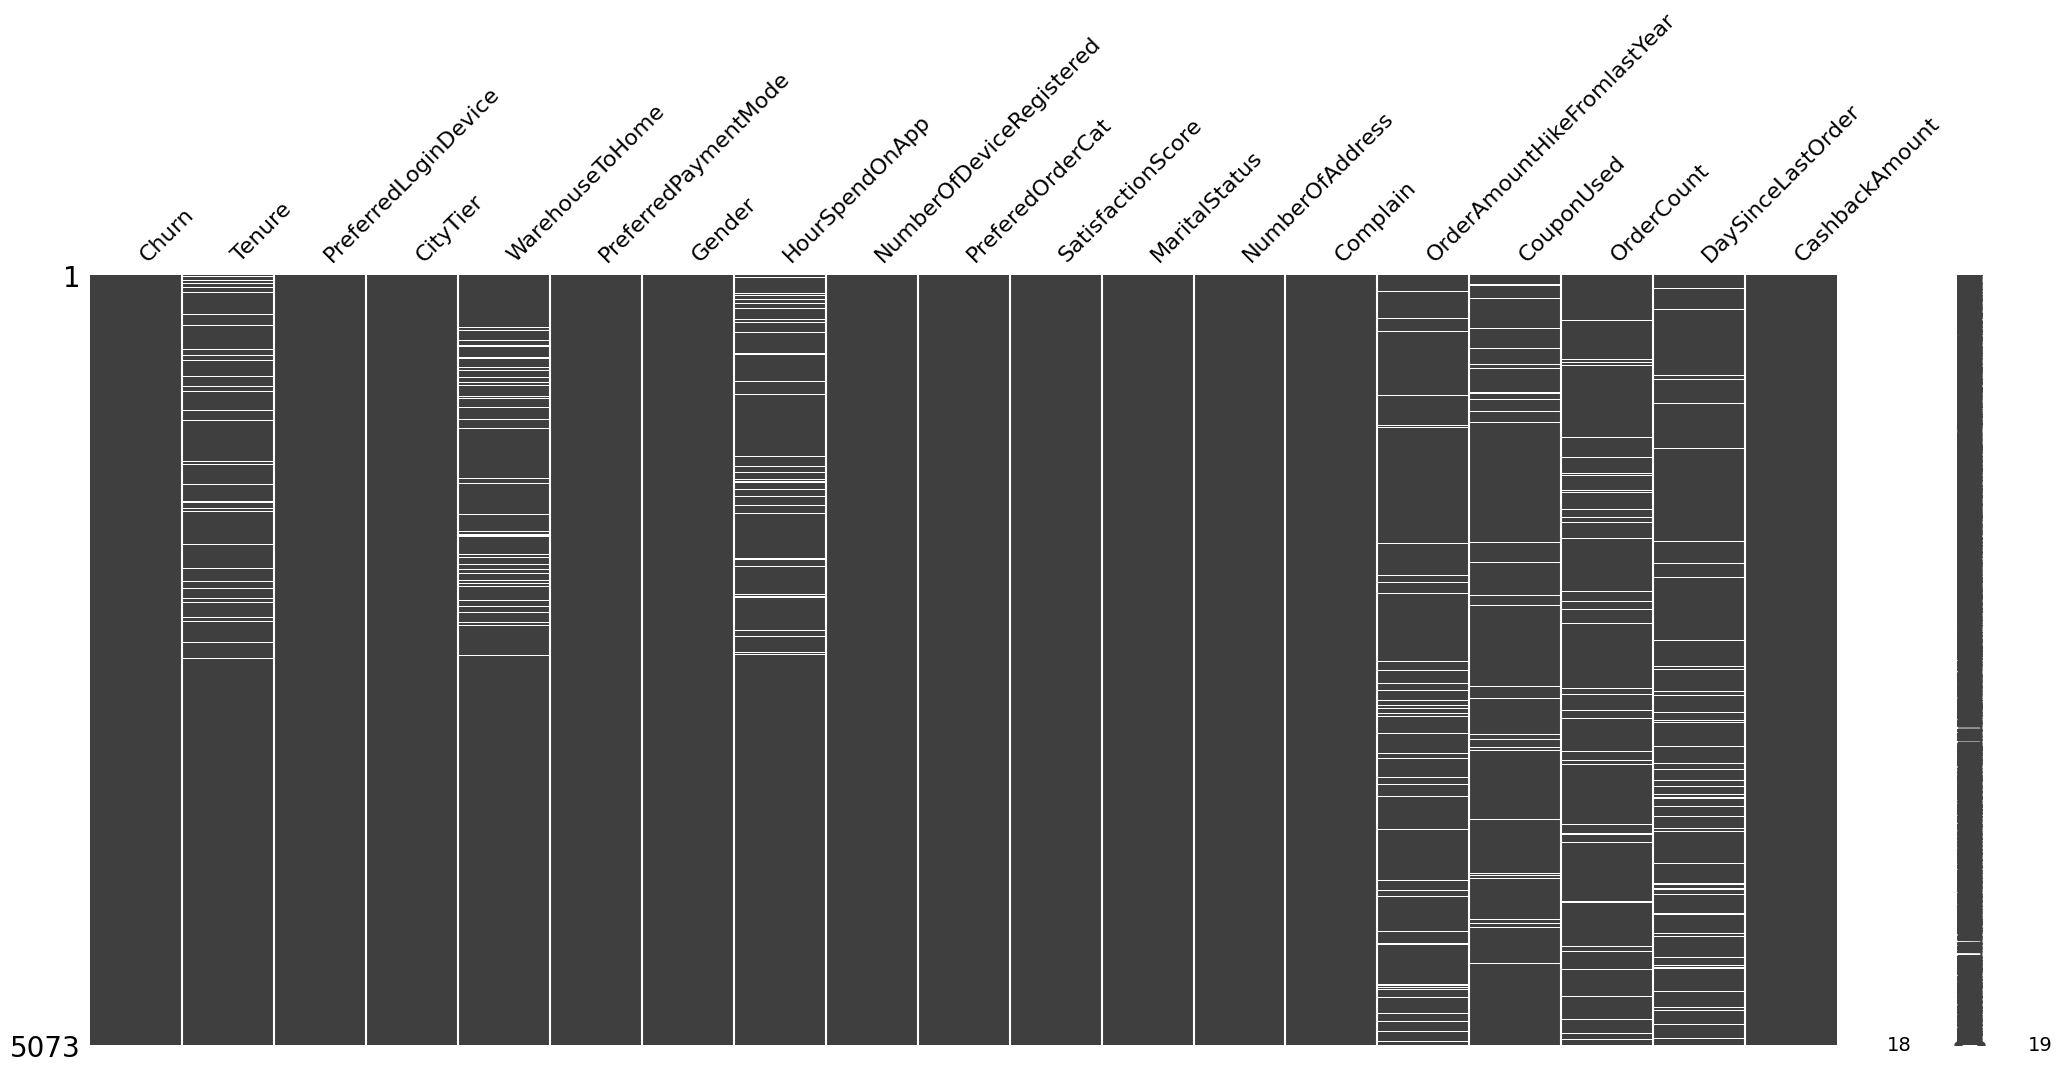

In [48]:
msno.matrix(df)

In [49]:
df.isnull().sum()*100/df.shape[0]

Churn                          0.000000
Tenure                         4.553519
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.356397
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.533806
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.967475
CouponUsed                     4.139562
OrderCount                     4.790065
DaySinceLastOrder              5.677114
CashbackAmount                 0.000000
dtype: float64

In [50]:
miss_col = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

In [51]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer

In [52]:
df_impute = df.copy()

In [53]:
mice_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear',
             'DaySinceLastOrder', 'OrderCount', 'CouponUsed']

In [54]:
mice_imputer = IterativeImputer(max_iter = 50, random_state = 0)
df_impute[mice_cols] = mice_imputer.fit_transform(df_impute[mice_cols])

In [55]:
df['Tenure'] = df_impute['Tenure']

In [56]:
del df_impute
df_impute1 = df.copy()

In [57]:
df.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [58]:
df_impute1.drop(['mapped_City_Tier'], axis = 1, inplace = True)

KeyError: "['mapped_City_Tier'] not found in axis"

In [59]:

df_impute1['Tenure'].dtype

dtype('float64')

In [60]:
knn_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 
             'DaySinceLastOrder', 'OrderCount', 'CouponUsed', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'CashbackAmount']
knn_imputer = KNNImputer(n_neighbors=5)
df_impute1[knn_cols] = knn_imputer.fit_transform(df_impute1[knn_cols])

In [61]:
df['WarehouseToHome'] = df_impute1['WarehouseToHome']
df['HourSpendOnApp']  = df_impute1['HourSpendOnApp']
df['DaySinceLastOrder'] = df_impute1['DaySinceLastOrder']
df['OrderAmountHikeFromlastYear'] = df_impute1['OrderAmountHikeFromlastYear']

In [62]:
 del df_impute1

In [63]:
median_imputer = SimpleImputer(strategy='median')
median_cols = ['OrderCount', 'CouponUsed']
df[median_cols] = median_imputer.fit_transform(df[median_cols])

In [64]:
df.isnull().sum()

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [65]:
df.head(7)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.000000,Mobile Phone,3,6.0,Card Payment,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,8.189374,Mobile Phone,1,8.0,Digital Payment,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,8.939270,Mobile Phone,1,30.0,Card Payment,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.000000,Mobile Phone,3,15.0,Card Payment,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.000000,Mobile Phone,1,12.0,Card Payment,Male,2.2,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,1,0.000000,Computer,1,22.0,Card Payment,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,1,8.415443,Mobile Phone,3,11.0,Cash Payment,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86


In [66]:
df['Digital_Engagement'] = df['HourSpendOnApp']* df['NumberOfDeviceRegistered']

In [67]:
df

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Digital_Engagement
0,1,4.000000,Mobile Phone,3,6.0,Card Payment,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93,9.0
1,1,8.189374,Mobile Phone,1,8.0,Digital Payment,Male,3.0,4,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90,12.0
2,1,8.939270,Mobile Phone,1,30.0,Card Payment,Male,2.0,4,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28,8.0
3,1,0.000000,Mobile Phone,3,15.0,Card Payment,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07,8.0
4,1,0.000000,Mobile Phone,1,12.0,Card Payment,Male,2.2,3,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60,6.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,0,5.000000,Computer,1,12.0,Card Payment,Male,4.0,4,Laptop & Accessory,5,Single,2,0,20.0,2.0,2.0,12.0,224.36,16.0
5624,0,1.000000,Mobile Phone,3,12.0,Digital Payment,Female,2.0,5,Mobile Phone,3,Single,2,0,19.0,2.0,2.0,1.0,154.66,10.0
5626,0,13.000000,Mobile Phone,1,13.0,Card Payment,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,8.6,224.91,15.0
5627,0,1.000000,Mobile Phone,1,11.0,Card Payment,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42,6.0


In [68]:
df.drop(['HourSpendOnApp', 'NumberOfDeviceRegistered'], axis = 1, inplace = True)

In [69]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(df[col].value_counts())
        print('---'*20)

PreferredLoginDevice
Mobile Phone    3616
Computer        1457
Name: count, dtype: int64
------------------------------------------------------------
PreferredPaymentMode
Card Payment       3694
Digital Payment     922
Cash Payment        457
Name: count, dtype: int64
------------------------------------------------------------
Gender
Male      3047
Female    2026
Name: count, dtype: int64
------------------------------------------------------------
PreferedOrderCat
Mobile Phone          1855
Laptop & Accessory    1847
Fashion                763
Grocery                366
Others                 242
Name: count, dtype: int64
------------------------------------------------------------
MaritalStatus
Married     2672
Single      1553
Divorced     848
Name: count, dtype: int64
------------------------------------------------------------


In [70]:
data = df[df.select_dtypes(exclude = np.number).columns]
data

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,Mobile Phone,Card Payment,Female,Laptop & Accessory,Single
1,Mobile Phone,Digital Payment,Male,Mobile Phone,Single
2,Mobile Phone,Card Payment,Male,Mobile Phone,Single
3,Mobile Phone,Card Payment,Male,Laptop & Accessory,Single
4,Mobile Phone,Card Payment,Male,Mobile Phone,Single
...,...,...,...,...,...
5623,Computer,Card Payment,Male,Laptop & Accessory,Single
5624,Mobile Phone,Digital Payment,Female,Mobile Phone,Single
5626,Mobile Phone,Card Payment,Male,Fashion,Married
5627,Mobile Phone,Card Payment,Male,Laptop & Accessory,Married


In [71]:
cat_cols = [col for col in df.columns if df[col].dtype=='object']

In [72]:
# df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dummy_na=False)

# print("DataFrame after One-Hot Encoding with drop_first=True:")



In [73]:
# df_encoded

In [74]:
#df_encoded.columns

Handling Outliers

In [75]:
# df_encoded.dtypes

In [76]:
num_cat = [col for col in df.columns if (df[col].dtypes=='float64' or df[col].dtypes=='int64')]


In [77]:
num_cat

['Churn',
 'Tenure',
 'CityTier',
 'WarehouseToHome',
 'SatisfactionScore',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount',
 'Digital_Engagement']

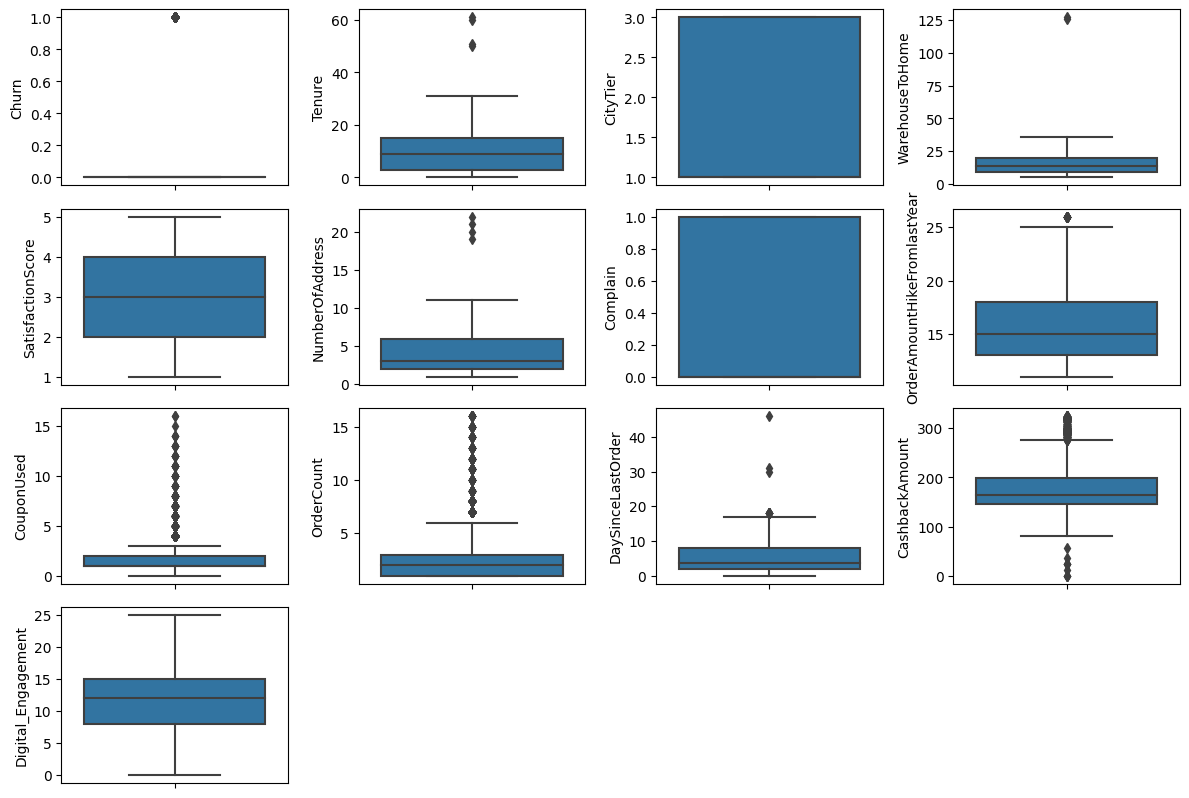

In [78]:
fig = plt.figure(figsize = (12,18))
i  = 0
for col in num_cat:
    fig.add_subplot(9,4,i+1)
    sns.boxplot(y = df.loc[:, col])
    i+=1
plt.tight_layout()
plt.show()

In [79]:
def range_finder(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    return upper, lower
    

def count_outlier(df, num_cat):
    dic = {}
    for col in num_cat:
        upper, lower = range_finder(df, col)
        outlier_count = df[(df[col] > upper ) | (df[col] < lower)].shape[0]
        dic[col] = outlier_count
    return dic
        
    

In [80]:
dic = count_outlier(df, num_cat)

In [81]:
dic

{'Churn': 841,
 'Tenure': 4,
 'CityTier': 0,
 'WarehouseToHome': 2,
 'SatisfactionScore': 0,
 'NumberOfAddress': 4,
 'Complain': 0,
 'OrderAmountHikeFromlastYear': 29,
 'CouponUsed': 610,
 'OrderCount': 673,
 'DaySinceLastOrder': 12,
 'CashbackAmount': 382,
 'Digital_Engagement': 0}

In [82]:
outlier_to_be_removed = ['Tenure', 'WarehouseToHome', 'NumberOfAddress', 'DaySinceLastOrder']

In [83]:
def handle_outliers(df , column_name):
  Q1 = df[column_name].quantile(0.25)
  Q3 = df[column_name].quantile(0.75)
  IQR = Q3 - Q1

  Upper = Q3 + IQR * 1.5
  lower = Q1 - IQR * 1.5

  return df[ (df[column_name] > lower) & (df[column_name] < Upper) ]


In [84]:
for col in outlier_to_be_removed:
    df = handle_outliers(df, col)

In [85]:
dic = count_outlier(df, outlier_to_be_removed)
dic

{'Tenure': 0,
 'WarehouseToHome': 0,
 'NumberOfAddress': 0,
 'DaySinceLastOrder': 0}

In [86]:
df

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Digital_Engagement
0,1,4.000000,Mobile Phone,3,6.0,Card Payment,Female,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93,9.0
1,1,8.189374,Mobile Phone,1,8.0,Digital Payment,Male,Mobile Phone,3,Single,7,1,15.0,0.0,1.0,0.0,120.90,12.0
2,1,8.939270,Mobile Phone,1,30.0,Card Payment,Male,Mobile Phone,3,Single,6,1,14.0,0.0,1.0,3.0,120.28,8.0
3,1,0.000000,Mobile Phone,3,15.0,Card Payment,Male,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07,8.0
4,1,0.000000,Mobile Phone,1,12.0,Card Payment,Male,Mobile Phone,5,Single,3,0,11.0,1.0,1.0,3.0,129.60,6.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,0,5.000000,Computer,1,12.0,Card Payment,Male,Laptop & Accessory,5,Single,2,0,20.0,2.0,2.0,12.0,224.36,16.0
5624,0,1.000000,Mobile Phone,3,12.0,Digital Payment,Female,Mobile Phone,3,Single,2,0,19.0,2.0,2.0,1.0,154.66,10.0
5626,0,13.000000,Mobile Phone,1,13.0,Card Payment,Male,Fashion,5,Married,6,0,16.0,1.0,2.0,8.6,224.91,15.0
5627,0,1.000000,Mobile Phone,1,11.0,Card Payment,Male,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42,6.0


In [87]:
#since there's been a significant increase in the number of columns as well as sparsity in the dataset, I'm try out K Fold Target Encoding...

In [88]:
from sklearn.model_selection import KFold

In [89]:
# K-Fold Target Encoding Function ---
def kfold_target_encode(df, categorical_features, target_col, n_splits=5):
    """
    Performs K-fold target encoding to prevent data leakage.
    
    Args:
        df (pd.DataFrame): The input DataFrame.
        categorical_features (list): A list of column names to encode.
        target_col (str): The name of the target column.
        n_splits (int): The number of folds for cross-validation.

    Returns:
        pd.DataFrame: A new DataFrame with the categorical features
                      replaced by their target-encoded values.
    """
    # Create a copy to avoid modifying the original DataFrame
    df_encoded = df.copy()
    
    # Store the overall mean of the target variable for validation/test sets
    overall_mean = df[target_col].mean()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for feature in categorical_features:
        # Create a new column to store the encoded values
        encoded_col_name = f"{feature}_encoded"
        df_encoded[encoded_col_name] = np.nan
        
        for train_index, val_index in kf.split(df_encoded):
            # Split data into training and validation sets for this fold
            X_train, X_val = df_encoded.iloc[train_index], df_encoded.iloc[val_index]
            
            # Calculate the mean target value for each category on the TRAINING data
            train_means = X_train.groupby(feature)[target_col].mean()
            
            # Map the validation data using the means from the training data
            df_encoded.loc[val_index, encoded_col_name] = (
                df_encoded.loc[val_index, feature].map(train_means)
            )
            
        # For any categories that didn't appear in a fold's training set,
        # fill with the overall mean to avoid NaNs.
        df_encoded[encoded_col_name].fillna(overall_mean, inplace=True)
    
    # Drop the original categorical columns
    df_encoded.drop(columns=categorical_features, inplace=True)

    return df_encoded





In [98]:
df_encoded  = df.reset_index(drop = True)

In [99]:
features_to_encode = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',	'PreferedOrderCat',	'MaritalStatus']
target_variable = 'Churn'

# Apply the k-fold target encoding
df_encoded = kfold_target_encode(df_encoded, features_to_encode, target_variable)

print("\n---")
print("Final DataFrame after K-Fold Target Encoding:")
print(df_encoded.head())

# Print the shape of the DataFrames to show the dimensionality change
print("\n---")
print(f"Original DataFrame shape: {df.shape}")
print(f"Final (encoded) DataFrame shape: {df_encoded.shape}")


---
Final DataFrame after K-Fold Target Encoding:
   Churn    Tenure  CityTier  WarehouseToHome  SatisfactionScore  \
0      1  4.000000         3              6.0                  2   
1      1  8.189374         1              8.0                  3   
2      1  8.939270         1             30.0                  3   
3      1  0.000000         3             15.0                  5   
4      1  0.000000         1             12.0                  5   

   NumberOfAddress  Complain  OrderAmountHikeFromlastYear  CouponUsed  \
0                9         1                         11.0         1.0   
1                7         1                         15.0         0.0   
2                6         1                         14.0         0.0   
3                8         0                         23.0         0.0   
4                3         0                         11.0         1.0   

   OrderCount  DaySinceLastOrder  CashbackAmount  Digital_Engagement  \
0         1.0                

In [100]:
df_encoded.head(10)

,Churn,Tenure,CityTier,WarehouseToHome,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Digital_Engagement,PreferredLoginDevice_encoded,PreferredPaymentMode_encoded,Gender_encoded,PreferedOrderCat_encoded,MaritalStatus_encoded
0,1,4.000000,3,6.0,2,9,1,11.0,1.0,1.0,5.0,159.93,9.0,0.150891,0.147959,0.154562,0.104110,0.271337
1,1,8.189374,1,8.0,3,7,1,15.0,0.0,1.0,0.0,120.90,12.0,0.155101,0.200820,0.173588,0.263729,0.267526
2,1,8.939270,1,30.0,3,6,1,14.0,0.0,1.0,3.0,120.28,8.0,0.155101,0.146575,0.173588,0.263729,0.267526
3,1,0.000000,3,15.0,5,8,0,23.0,0.0,1.0,3.0,134.07,8.0,0.158223,0.144603,0.174289,0.105263,0.268781
4,1,0.000000,1,12.0,5,3,0,11.0,1.0,1.0,3.0,129.60,6.6,0.158223,0.144603,0.174289,0.257781,0.268781
5,1,0.000000,1,22.0,5,2,1,22.0,4.0,6.0,7.0,139.19,15.0,0.188482,0.144603,0.155528,0.257781,0.268781
6,1,8.415443,3,11.0,2,4,0,14.0,0.0,1.0,0.0,120.86,6.0,0.150891,0.244382,0.172528,0.104110,0.140762
7,1,8.574282,1,6.0,2,3,1,16.0,2.0,2.0,0.0,122.93,9.0,0.157913,0.149865,0.179413,0.269518,0.151917
8,1,13.000000,3,9.0,3,2,1,14.0,0.0,1.0,2.0,126.83,10.4,0.152121,0.201910,0.174845,0.266802,0.154321
9,1,8.245230,1,31.0,3,2,0,12.0,1.0,1.0,1.0,122.93,10.0,0.158223,0.144603,0.174289,0.257781,0.268781


In [139]:
df_encoded.drop(['mapped_City_Tier'], axis = 1, inplace = True)

KeyError: "['mapped_City_Tier'] not found in axis"

In [106]:
df_encoded.isnull().sum()

Churn                           0
Tenure                          0
CityTier                        0
WarehouseToHome                 0
SatisfactionScore               0
NumberOfAddress                 0
Complain                        0
OrderAmountHikeFromlastYear     0
CouponUsed                      0
OrderCount                      0
DaySinceLastOrder               0
CashbackAmount                  0
Digital_Engagement              0
PreferredLoginDevice_encoded    0
PreferredPaymentMode_encoded    0
Gender_encoded                  0
PreferedOrderCat_encoded        0
MaritalStatus_encoded           0
dtype: int64

<Axes: >

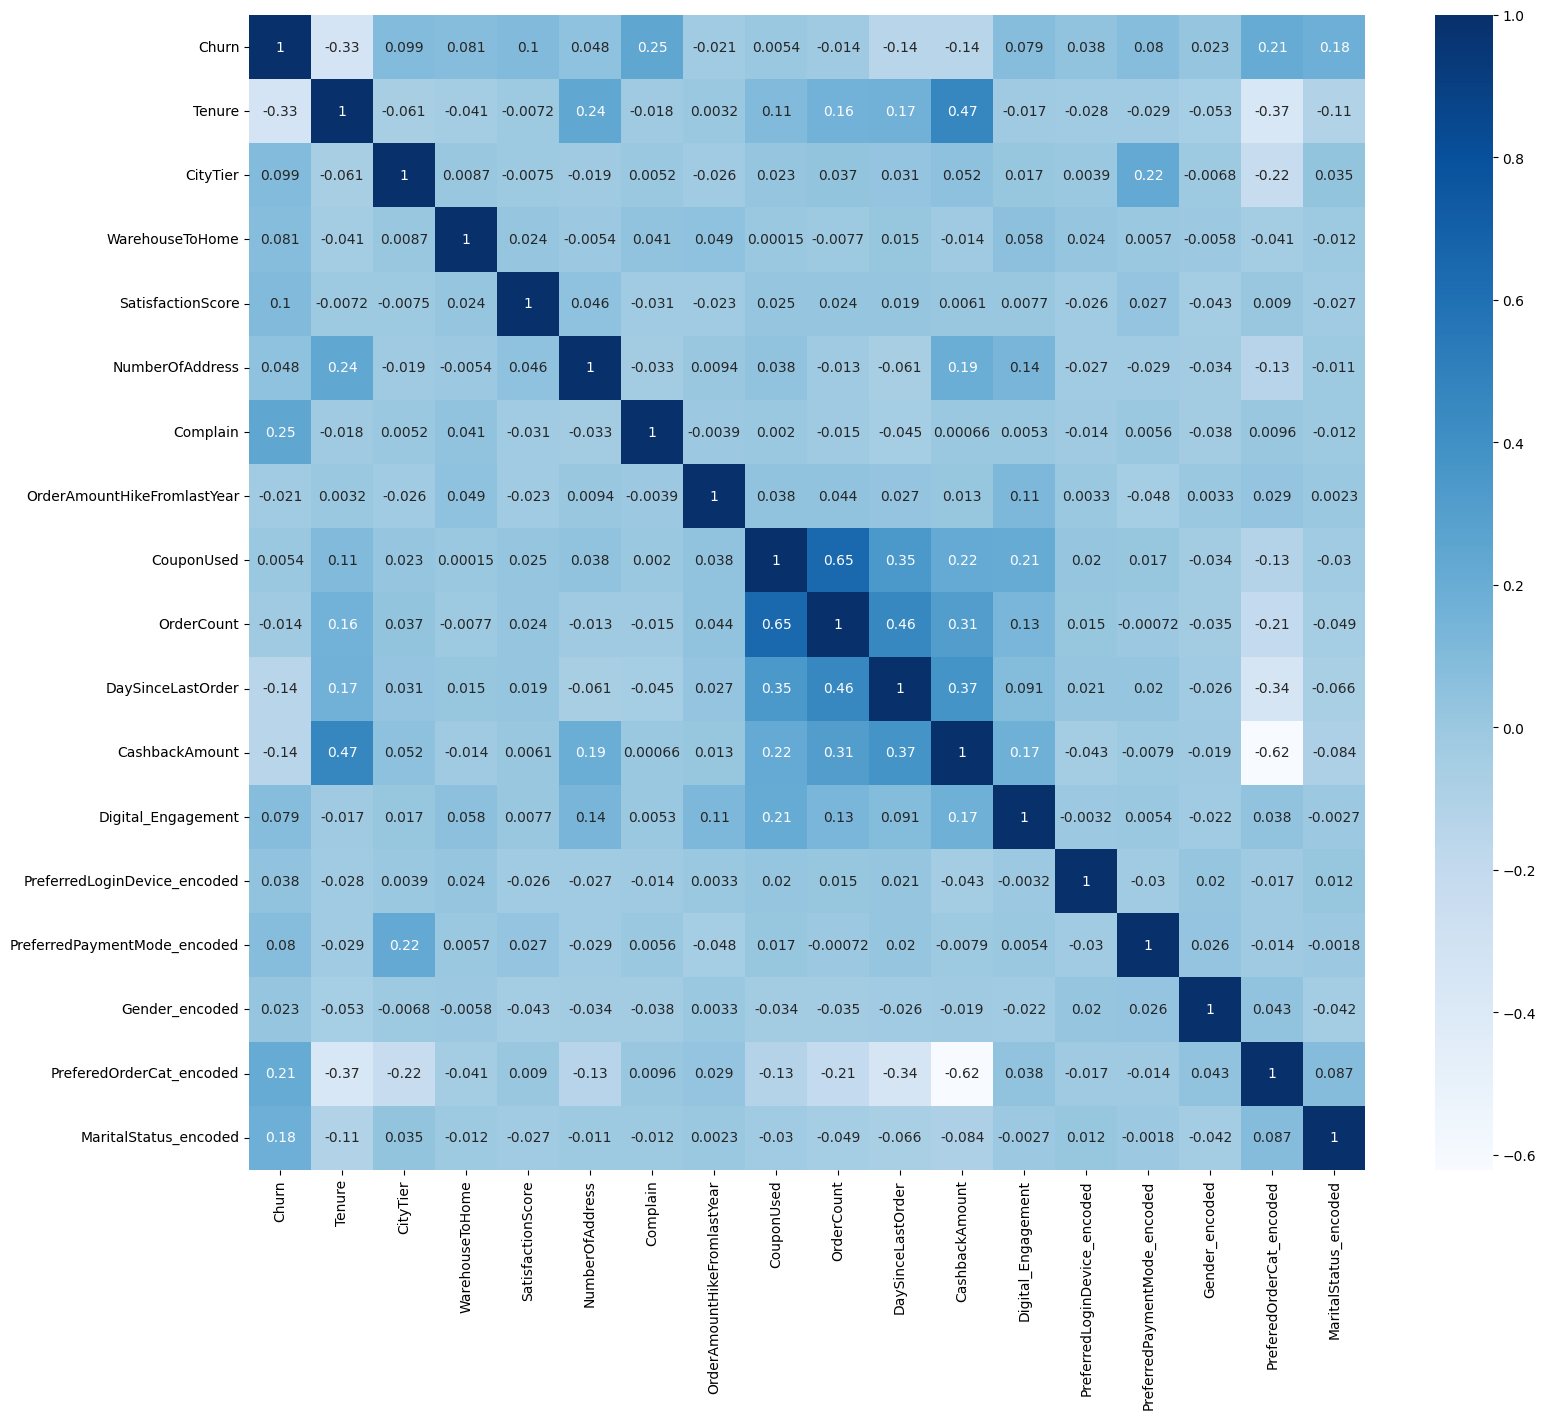

In [107]:
plt.figure(figsize = (18,15))
sns.heatmap(df_encoded.corr(), annot = True, cmap = 'Blues')

In [108]:
df_encoded

,Churn,Tenure,CityTier,WarehouseToHome,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Digital_Engagement,PreferredLoginDevice_encoded,PreferredPaymentMode_encoded,Gender_encoded,PreferedOrderCat_encoded,MaritalStatus_encoded
0,1,4.000000,3,6.0,2,9,1,11.0,1.0,1.0,5.0,159.93,9.0,0.150891,0.147959,0.154562,0.104110,0.271337
1,1,8.189374,1,8.0,3,7,1,15.0,0.0,1.0,0.0,120.90,12.0,0.155101,0.200820,0.173588,0.263729,0.267526
2,1,8.939270,1,30.0,3,6,1,14.0,0.0,1.0,3.0,120.28,8.0,0.155101,0.146575,0.173588,0.263729,0.267526
3,1,0.000000,3,15.0,5,8,0,23.0,0.0,1.0,3.0,134.07,8.0,0.158223,0.144603,0.174289,0.105263,0.268781
4,1,0.000000,1,12.0,5,3,0,11.0,1.0,1.0,3.0,129.60,6.6,0.158223,0.144603,0.174289,0.257781,0.268781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5030,0,5.000000,1,12.0,5,2,0,20.0,2.0,2.0,12.0,224.36,16.0,0.187609,0.146575,0.173588,0.106297,0.267526
5031,0,1.000000,3,12.0,3,2,0,19.0,2.0,2.0,1.0,154.66,10.0,0.152121,0.201910,0.154710,0.266802,0.265109
5032,0,13.000000,1,13.0,5,6,0,16.0,1.0,2.0,8.6,224.91,15.0,0.157913,0.149865,0.179413,0.163430,0.116224
5033,0,1.000000,1,11.0,4,3,1,21.0,1.0,2.0,4.0,186.42,6.0,0.150891,0.147959,0.172528,0.104110,0.110741


In [110]:
import plotly.express as px
fig = px.histogram(df_encoded, x = 'Churn', color = "Churn", text_auto =True, title = "<b>" + 'Checking Imbalance', color_discrete_sequence = ['#BA1F33','#3A506B'])
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='Churn',
yaxis_title='count',
)
fig.show()

In [111]:
X = df_encoded.drop(['Churn'], axis = 1)
Y = df_encoded['Churn']

In [112]:
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaled_X = scaler_X.fit_transform(X)
X_scaled = pd.DataFrame(scaled_X, columns = X.columns)
df_encoded = pd.concat([X_scaled, Y], axis=1)

In [113]:
df_encoded

,Tenure,CityTier,WarehouseToHome,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Digital_Engagement,PreferredLoginDevice_encoded,PreferredPaymentMode_encoded,Gender_encoded,PreferedOrderCat_encoded,MaritalStatus_encoded,Churn
0,-0.733315,1.459845,-1.163171,-0.741926,1.892513,1.589311,-1.298981,-0.402473,-0.697548,0.100055,-0.355608,-0.423270,-0.832468,-0.534394,-1.118745,-0.788593,1.528338,1
1,-0.228490,-0.716416,-0.917571,-0.018534,1.106470,1.589311,-0.192956,-0.929508,-0.697548,-1.335692,-1.148733,0.224605,-0.605495,0.992366,0.672571,1.232355,1.472806,1
2,-0.138127,-0.716416,1.784036,-0.018534,0.713449,1.589311,-0.469462,-0.929508,-0.697548,-0.474244,-1.161332,-0.639229,-0.605495,-0.574364,0.672571,1.232355,1.472806,1
3,-1.215320,1.459845,-0.057969,1.428251,1.499491,-0.629203,2.019094,-0.929508,-0.697548,-0.474244,-0.881107,-0.639229,-0.437132,-0.631335,0.738591,-0.773988,1.491098,1
4,-1.215320,-0.716416,-0.426370,1.428251,-0.465615,-0.629203,-1.298981,-0.402473,-0.697548,-0.474244,-0.971941,-0.941571,-0.437132,-0.631335,0.738591,1.157047,1.491098,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5030,-0.612814,-0.716416,-0.426370,1.428251,-0.858636,-0.629203,1.189575,0.124562,-0.351079,2.110100,0.953670,1.088440,1.147151,-0.574364,0.672571,-0.760904,1.472806,0
5031,-1.094819,1.459845,-0.426370,-0.018534,-0.858636,-0.629203,0.913069,0.124562,-0.351079,-1.048543,-0.462699,-0.207312,-0.766160,1.023856,-1.104854,1.271271,1.437574,0
5032,0.351197,-0.716416,-0.303569,1.428251,0.713449,-0.629203,0.083550,-0.402473,-0.351079,1.133792,0.964846,0.872481,-0.453861,-0.479358,1.221004,-0.037528,-0.732282,0
5033,-1.094819,-0.716416,-0.549170,0.704859,-0.465615,1.589311,1.466082,-0.402473,-0.351079,-0.187095,0.182694,-1.071146,-0.832468,-0.534394,0.572758,-0.788593,-0.812184,0


In [114]:
pip install Tensorflow

Note: you may need to restart the kernel to use updated packages.


In [115]:
pip install imblearn 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 48.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [116]:
X = df_encoded.drop('Churn' , axis = 1)
Y = df_encoded['Churn']

In [142]:
df_encoded.to_csv("df_encoded_churn.csv", index = False)

In [119]:
!pip uninstall -y scikit-learn
!pip install scikit-learn

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
  Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 83.1 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


In [117]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [128]:
pip install --upgrade scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 9.0 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
Note: you may need to restart the kernel to use updated packages.


In [136]:
pip list

Package                               Version             Editable project location
------------------------------------- ------------------- -------------------------
absl-py                               1.4.0
accelerate                            1.8.1
aiofiles                              22.1.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.12.13
aiosignal                             1.3.2
aiosqlite                             0.21.0
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.11.1
alembic                               1.16.2
altair                                5.5.0
annotated-types                       0.7.0
annoy                                 1.17.3
ansicolors                            1.1.8
antlr4-python3-runtime                4.9.3
anyio                                 4.9.0
argon2-cffi                     

In [140]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
smt = SMOTETomek(random_state= 42)

ImportError: cannot import name 'UnsetMetadataPassedError' from 'sklearn.exceptions' (/usr/local/lib/python3.11/dist-packages/sklearn/exceptions.py)

In [124]:
from sklearn.utils import all_estimators

all_estimators()

ImportError: cannot import name 'ClassifierTags' from 'sklearn.utils' (/usr/local/lib/python3.11/dist-packages/sklearn/utils/__init__.py)

In [122]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [123]:
!pip install --upgrade numpy scipy
!pip install numpy --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 75.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 48.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.3.2 which is incompatible

In [ ]:
x_over , y_over = smt.fit_resample(X , Y)
x_over.shape, y_over.shape

In [125]:
import sklearn
print(sklearn.__version__)

1.2.2
